In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
# this is for jupyter notebook to show the plot in the notebook itself instead of opening a new window
%matplotlib inline

df=pd.read_csv('D:/DS_Content_Monetization_Modeler/Doc/youtube_ad_revenue_dataset.csv')


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [3]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [4]:
df.tail()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811
122399,vid_1056,2024-06-25 10:50:40.993199,9931,770.0,NaN,38466.837135,27.305703,517587,Tech,TV,CA,253.842824


In [5]:
df.columns.tolist()

['video_id',
 'date',
 'views',
 'likes',
 'comments',
 'watch_time_minutes',
 'video_length_minutes',
 'subscribers',
 'category',
 'device',
 'country',
 'ad_revenue_usd']

In [6]:
df['video_id'].nunique()

5000

In [7]:
# Unique video IDs
df['video_id'].unique()

array(['vid_3092', 'vid_3459', 'vid_4784', ..., 'vid_4757', 'vid_3953',
       'vid_2224'], shape=(5000,), dtype=object)

In [8]:
# Calculate the number of missing values in the 'video_id' column is Ok .No missing values
df['video_id'].isnull().sum()

np.int64(0)

In [9]:
df.date.unique()


array(['2024-09-24 10:50:40.993199', '2024-09-22 10:50:40.993199',
       '2024-11-21 10:50:40.993199', '2025-01-28 10:50:40.993199',
       '2025-04-28 10:50:40.993199', '2025-03-31 10:50:40.993199',
       '2024-12-10 10:50:40.993199', '2025-04-05 10:50:40.993199',
       '2025-02-17 10:50:40.993199', '2025-04-16 10:50:40.993199',
       '2025-01-05 10:50:40.993199', '2025-01-08 10:50:40.993199',
       '2024-06-11 10:50:40.993199', '2025-05-16 10:50:40.993199',
       '2025-02-01 10:50:40.993199', '2025-05-19 10:50:40.993199',
       '2025-03-08 10:50:40.993199', '2025-03-16 10:50:40.993199',
       '2024-07-27 10:50:40.993199', '2025-01-18 10:50:40.993199',
       '2024-11-27 10:50:40.993199', '2025-03-25 10:50:40.993199',
       '2024-12-03 10:50:40.993199', '2024-06-12 10:50:40.993199',
       '2025-06-02 10:50:40.993199', '2025-05-17 10:50:40.993199',
       '2025-03-17 10:50:40.993199', '2025-01-31 10:50:40.993199',
       '2024-11-22 10:50:40.993199', '2025-01-22 10:50:40.9931

In [10]:
# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d %H:%M:%S.%f")


In [11]:
df.views.unique()


array([ 9936, 10017, 10097, 10034,  9889, 10002,  9989, 10051,  9934,
        9907, 10052,  9990, 10106,  9999,  9979, 10024, 10070, 10026,
       10094, 10092,  9943, 10073,  9804,  9774,  9794,  9960,  9942,
       10125, 10053,  9795,  9780,  9920, 10021,  9949, 10247,  9928,
        9868,  9893, 10035,  9968, 10085, 10133, 10098,  9964, 10001,
        9929, 10151, 10166, 10180,  9987, 10013,  9982, 10039, 10091,
       10117,  9853, 10236, 10028,  9978,  9914,  9913,  9763, 10211,
       10105,  9973,  9828,  9958, 10037,  9947, 10202, 10090, 10107,
       10145,  9921,  9925, 10064,  9910,  9801,  9996,  9849, 10060,
       10170, 10062,  9903,  9866,  9965, 10186, 10033, 10122,  9816,
        9974,  9983,  9955, 10025,  9972,  9966,  9852, 10161, 10128,
       10273,  9944,  9950,  9937,  9939,  9988, 10058,  9991, 10008,
        9793,  9878,  9857, 10096,  9851,  9888, 10044, 10118, 10031,
       10050, 10087, 10022, 10071, 10063, 10015, 10076, 10132,  9902,
        9969, 10120,

In [12]:
# Check for missing values in the 'views' column-Found No missing values
df.views.isnull().sum()

np.int64(0)

In [13]:
df.likes.unique()

array([1221.,  642., 1979., ..., 2038., 2044., 2036.], shape=(1856,))

In [14]:
# Check for missing values in the 'likes' column-Found Missing values  
df.likes.isnull().sum()

np.int64(6117)

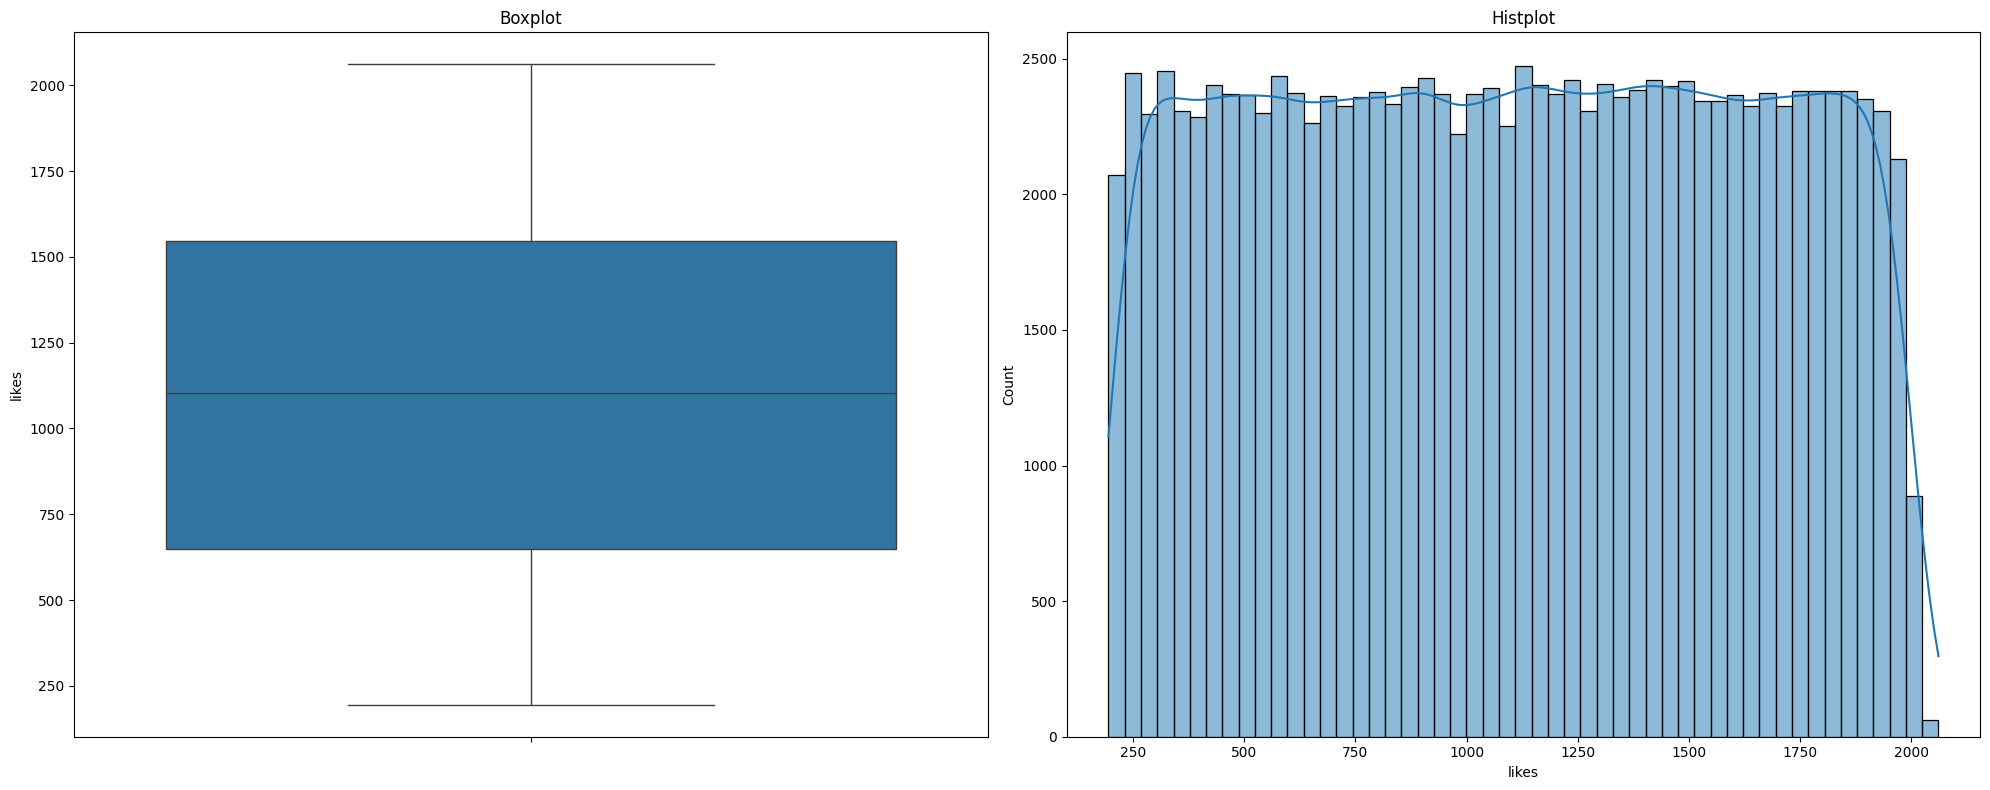

In [15]:
plt.figure(figsize=(20,8))
# First subplot (left)
plt.subplot(1,2,1)
sns.boxplot(data=df, y='likes')
plt.title('Boxplot')
# Second subplot (right)
plt.subplot(1,2,2)
sns.histplot(data=df, x='likes', kde=True)
plt.title('Histplot')
plt.tight_layout()
plt.show()

In [16]:
df['likes_clean'] = df['likes'].astype(str).str.strip()

In [17]:
df['likes'] = pd.to_numeric(df['likes_clean'], errors='coerce')

In [18]:
from sklearn.impute import KNNImputer
import pandas as pd

# Step 1: Select relevant numeric columns including the target
cols_for_imputation = ['likes', 'views', 'video_length_minutes', 'subscribers']
df_subset = df[cols_for_imputation]

# Step 2: Initialize and apply KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_imputed_array = imputer.fit_transform(df_subset)

# Step 3: Convert back to DataFrame
df_imputed = pd.DataFrame(df_imputed_array, columns=cols_for_imputation)

# Step 4: Replace only the 'likes' column in the original DataFrame
df['likes'] = df_imputed['likes']


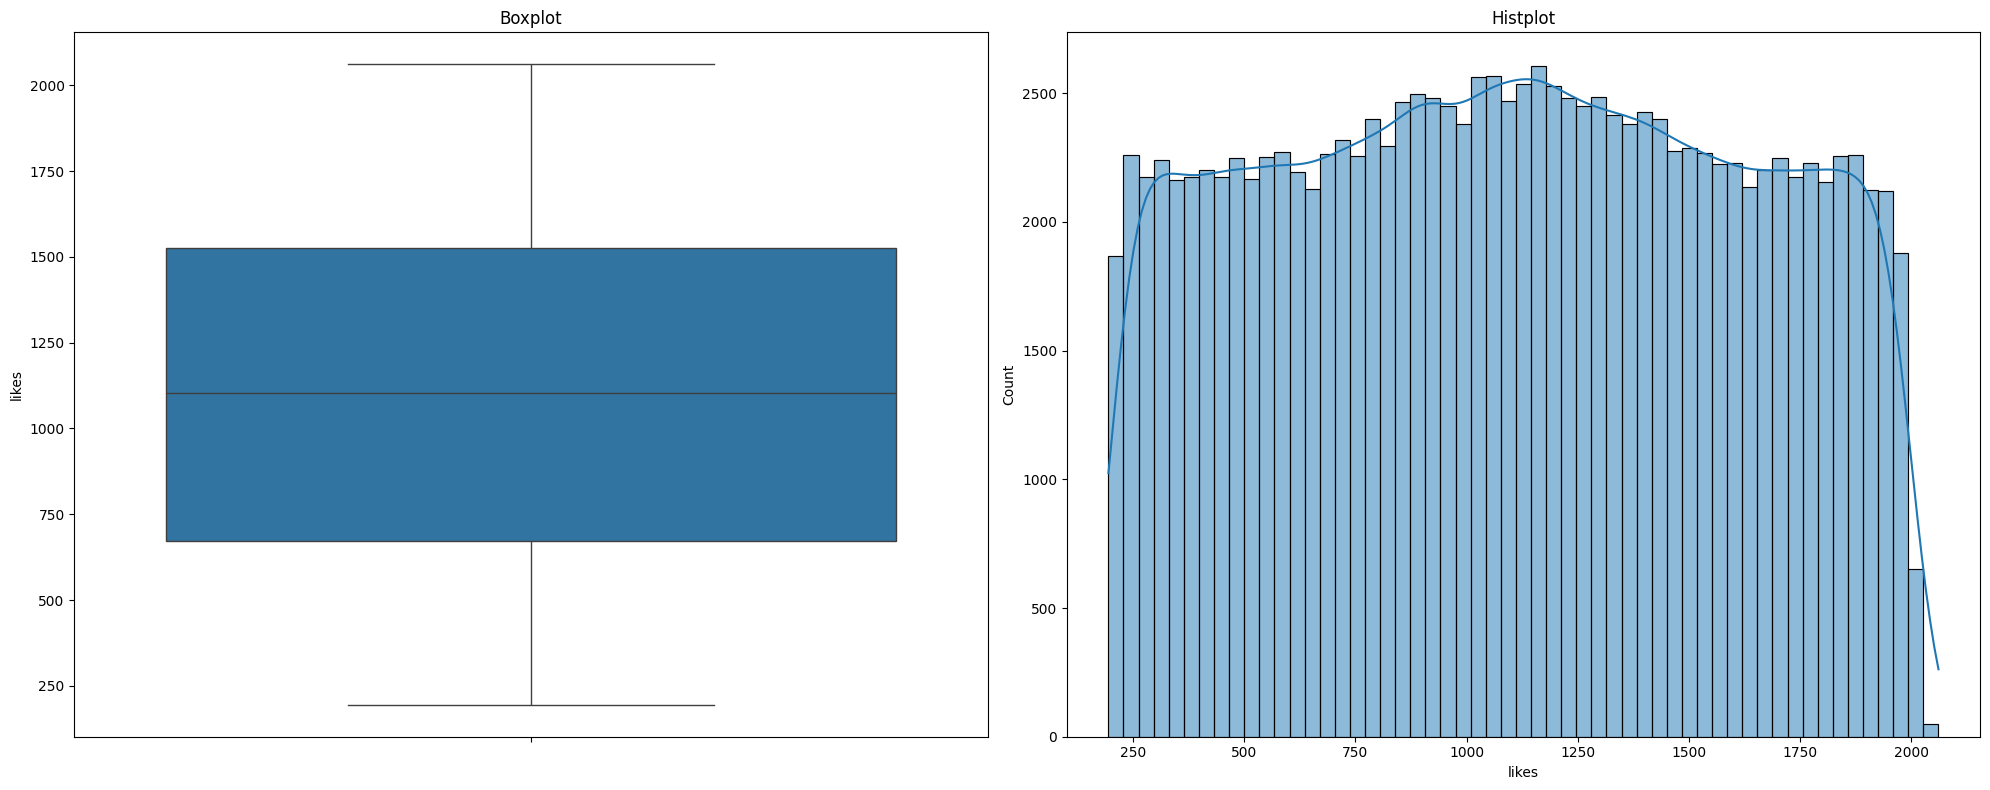

In [19]:
plt.figure(figsize=(20,8))
# First subplot (left)
plt.subplot(1,2,1)
sns.boxplot(data=df, y='likes')
plt.title('Boxplot')
# Second subplot (right)
plt.subplot(1,2,2)
sns.histplot(data=df, x='likes', kde=True)
plt.title('Histplot')
plt.tight_layout()
plt.show()

In [20]:
df['likes']=df['likes'].astype(int)

In [21]:
df['comments'].unique

<bound method Series.unique of 0         320.0
1         346.0
2         187.0
3         242.0
4         477.0
          ...  
122395    147.0
122396     63.0
122397      NaN
122398    106.0
122399      NaN
Name: comments, Length: 122400, dtype: float64>

In [22]:
df['comments'].isnull().sum()

np.int64(6112)

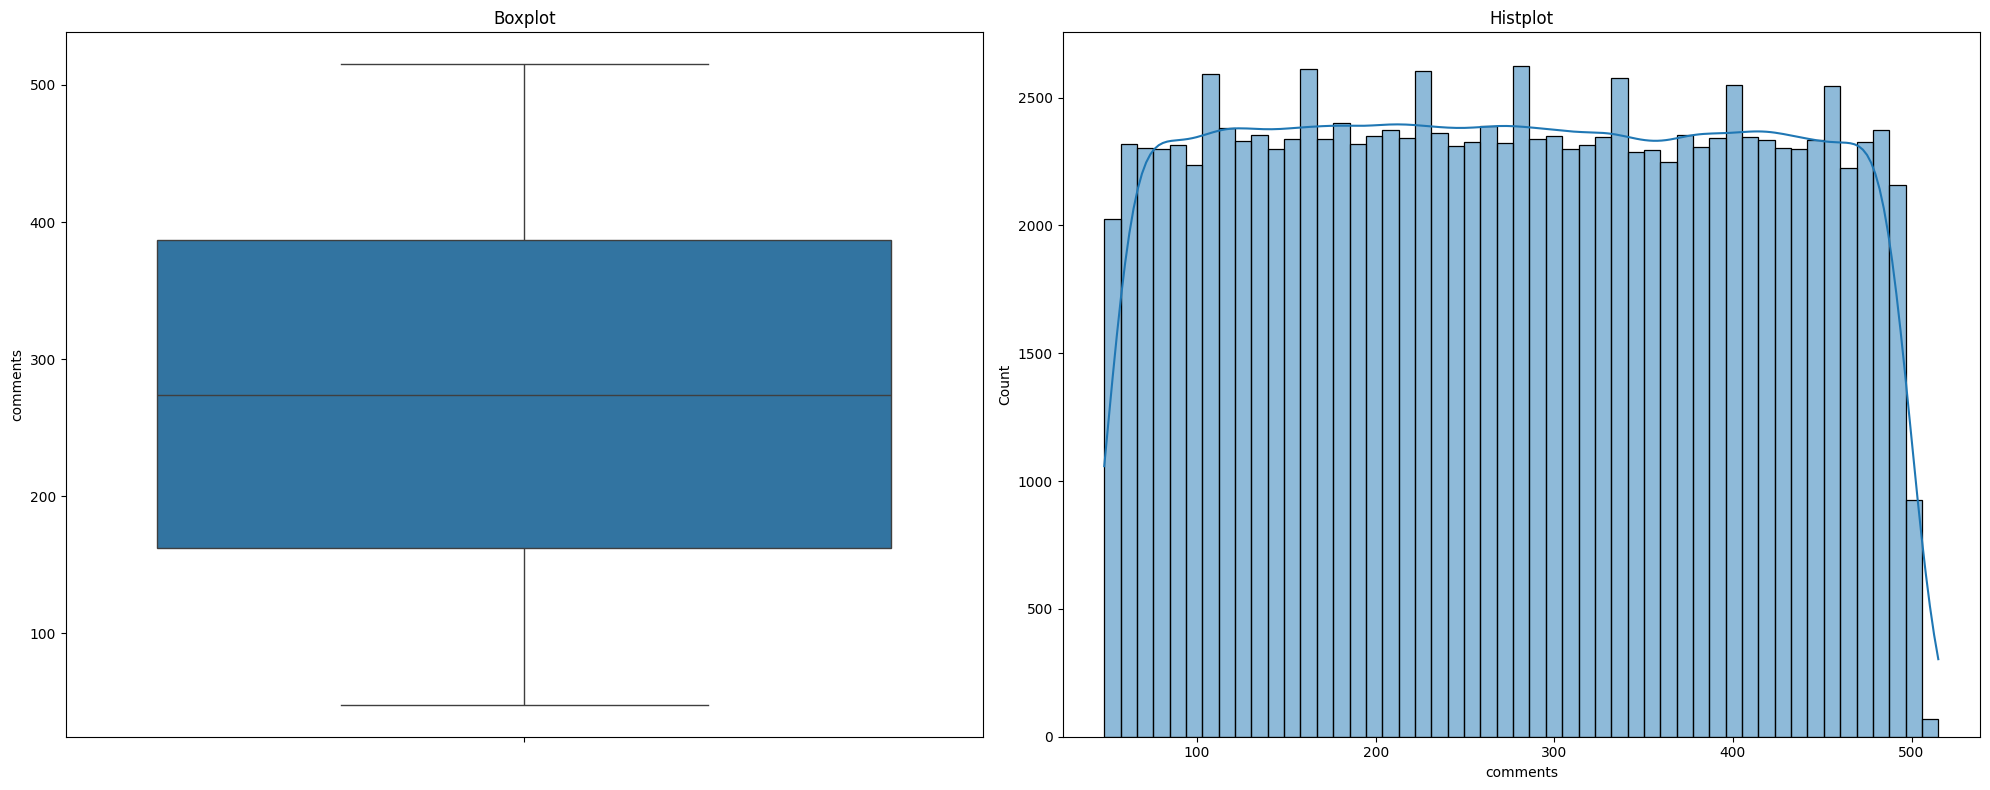

In [23]:
plt.figure(figsize=(20,8))
# First subplot (left)
plt.subplot(1,2,1)
sns.boxplot(data=df, y='comments')
plt.title('Boxplot')
# Second subplot (right)
plt.subplot(1,2,2)
sns.histplot(data=df, x='comments', kde=True)
plt.title('Histplot')
plt.tight_layout()
plt.show()


In [24]:
# KNNImputer for filling the missing values in 'comments'
comm =['likes', 'views', 'video_length_minutes', 'subscribers','comments']
df_comm=df[comm]
imputer=KNNImputer(n_neighbors=5)
df_imputed_array_coloums=imputer.fit_transform(df_comm)
df_imputed1= pd.DataFrame(df_imputed_array_coloums, columns=comm)
df['comments'] = df_imputed1['comments']

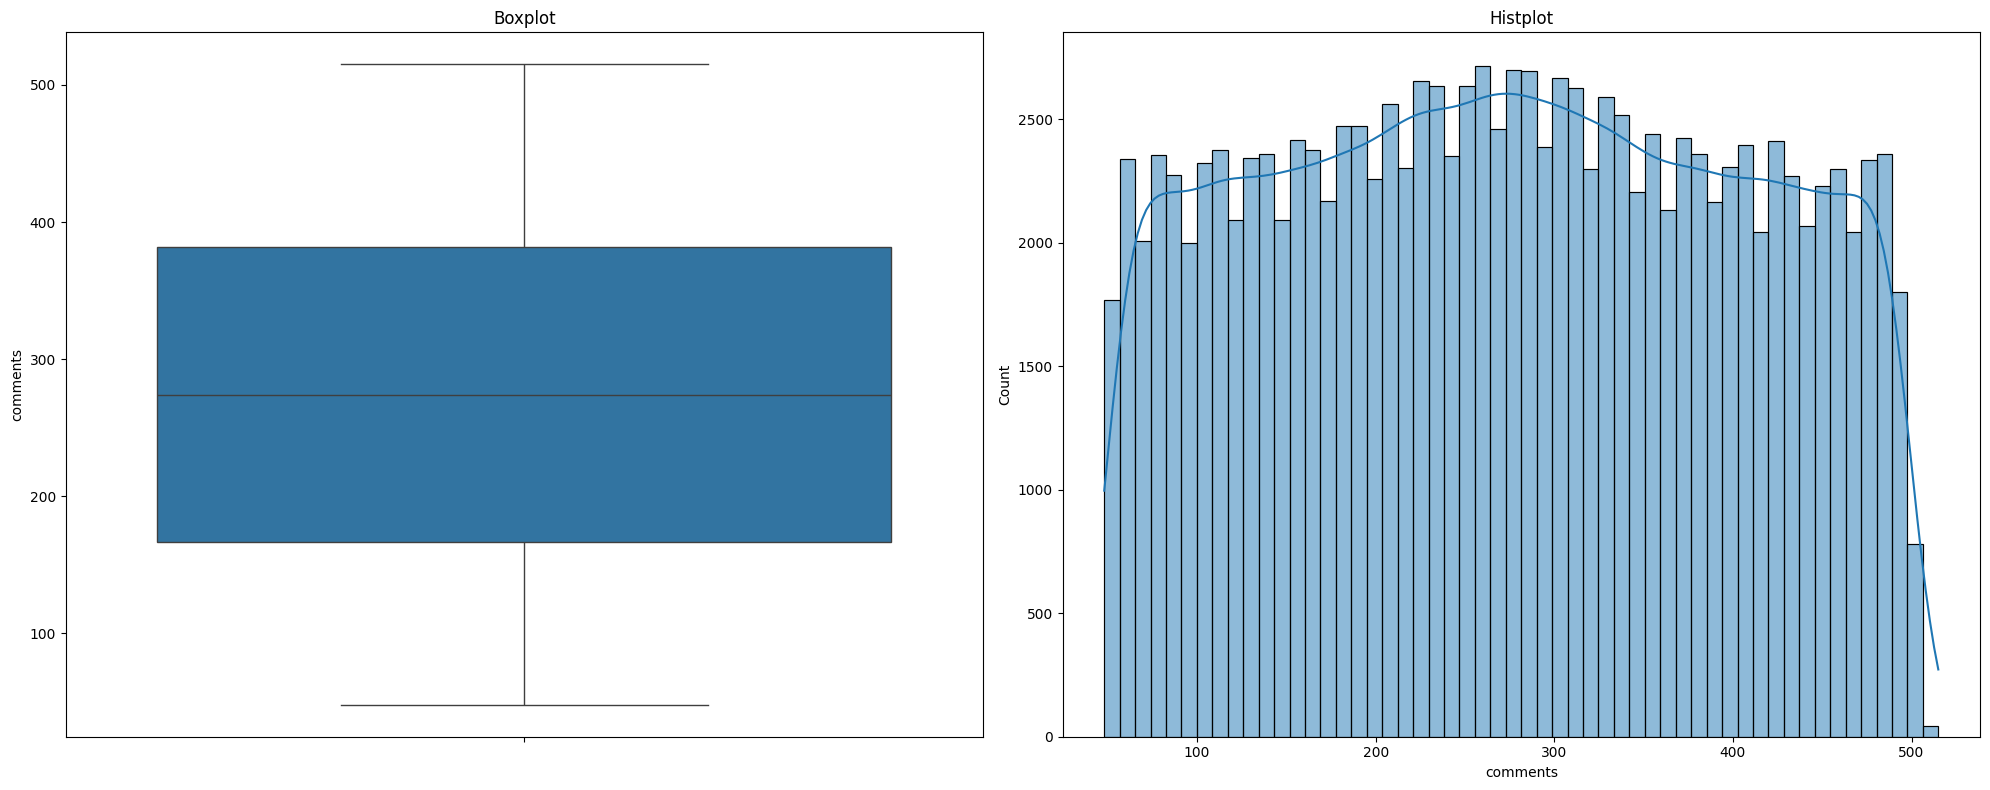

In [25]:
plt.figure(figsize=(20,8))
# First subplot (left)
plt.subplot(1,2,1)
sns.boxplot(data=df, y='comments')
plt.title('Boxplot')
# Second subplot (right)
plt.subplot(1,2,2)
sns.histplot(data=df, x='comments', kde=True)
plt.title('Histplot')
plt.tight_layout()
plt.show()

In [26]:
df['comments'].astype(int)

0         320
1         346
2         187
3         242
4         477
         ... 
122395    147
122396     63
122397    297
122398    106
122399    124
Name: comments, Length: 122400, dtype: int64

In [27]:
df['watch_time_minutes'].isnull().sum()

np.int64(6105)

In [28]:
#KNNImputer for filling the null values in 'watch_time_minutes'

watchtime=['likes', 'views', 'video_length_minutes', 'subscribers','comments','watch_time_minutes']
df_sub_watchtime = df[watchtime]
imputer=KNNImputer(n_neighbors=5)
df_arry_watchtime=imputer.fit_transform(df_sub_watchtime)
df_filled_watchtime=pd.DataFrame(df_arry_watchtime,columns=watchtime)
df['watch_time_minutes'] = df_filled_watchtime['watch_time_minutes']



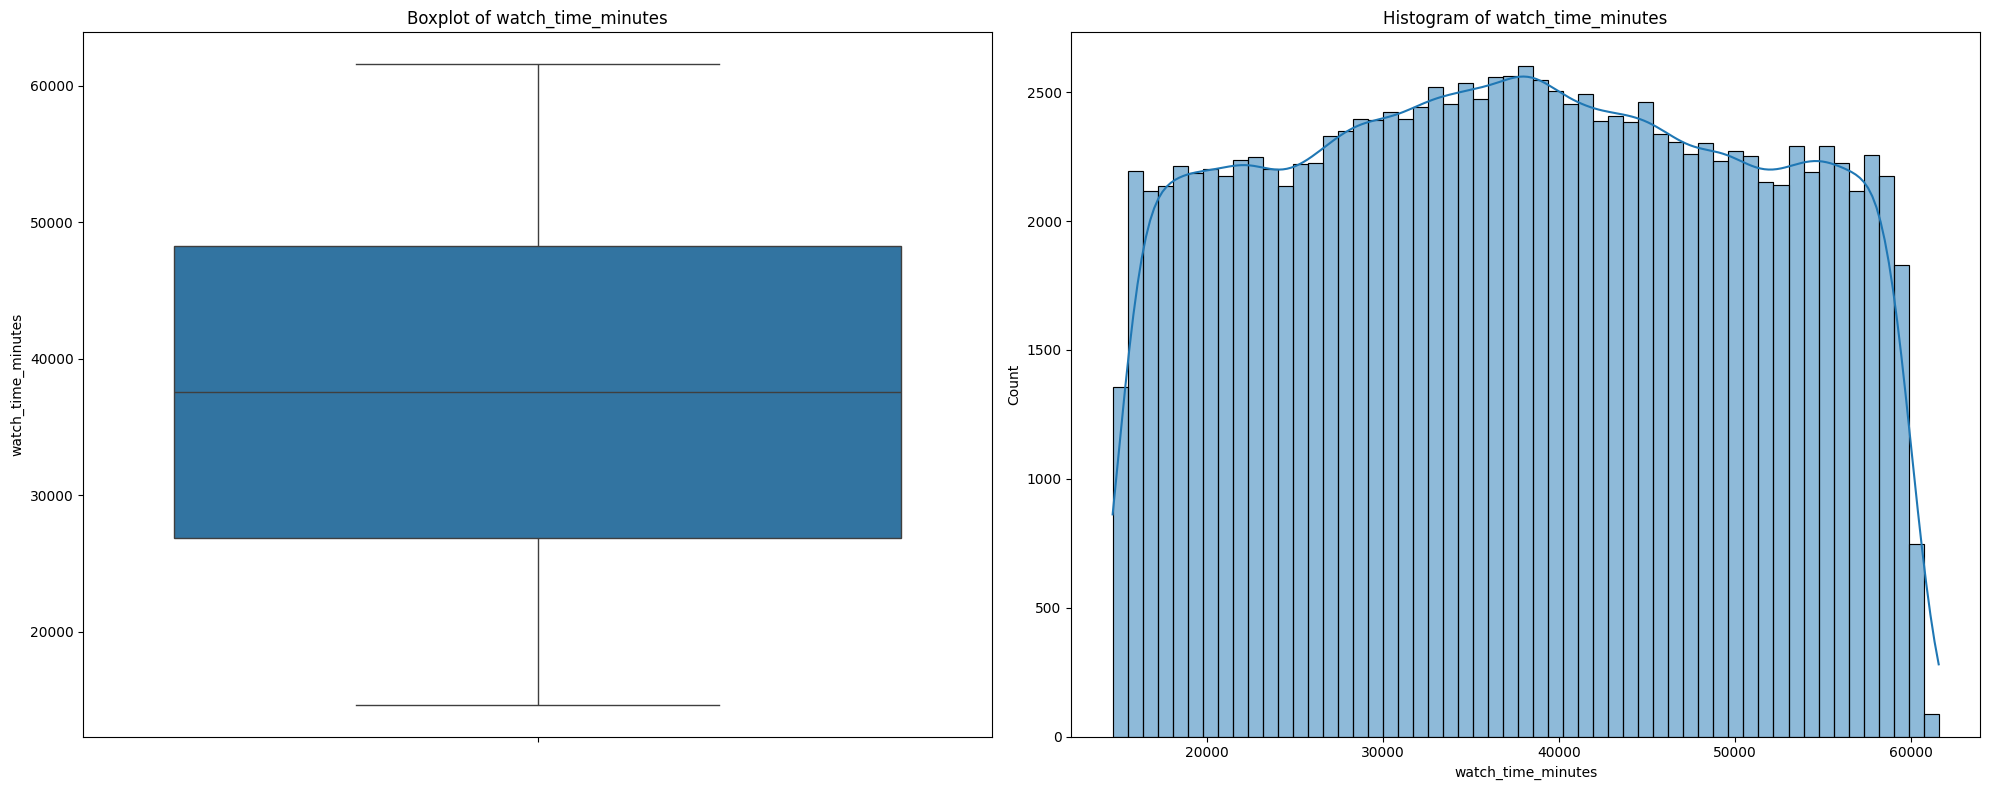

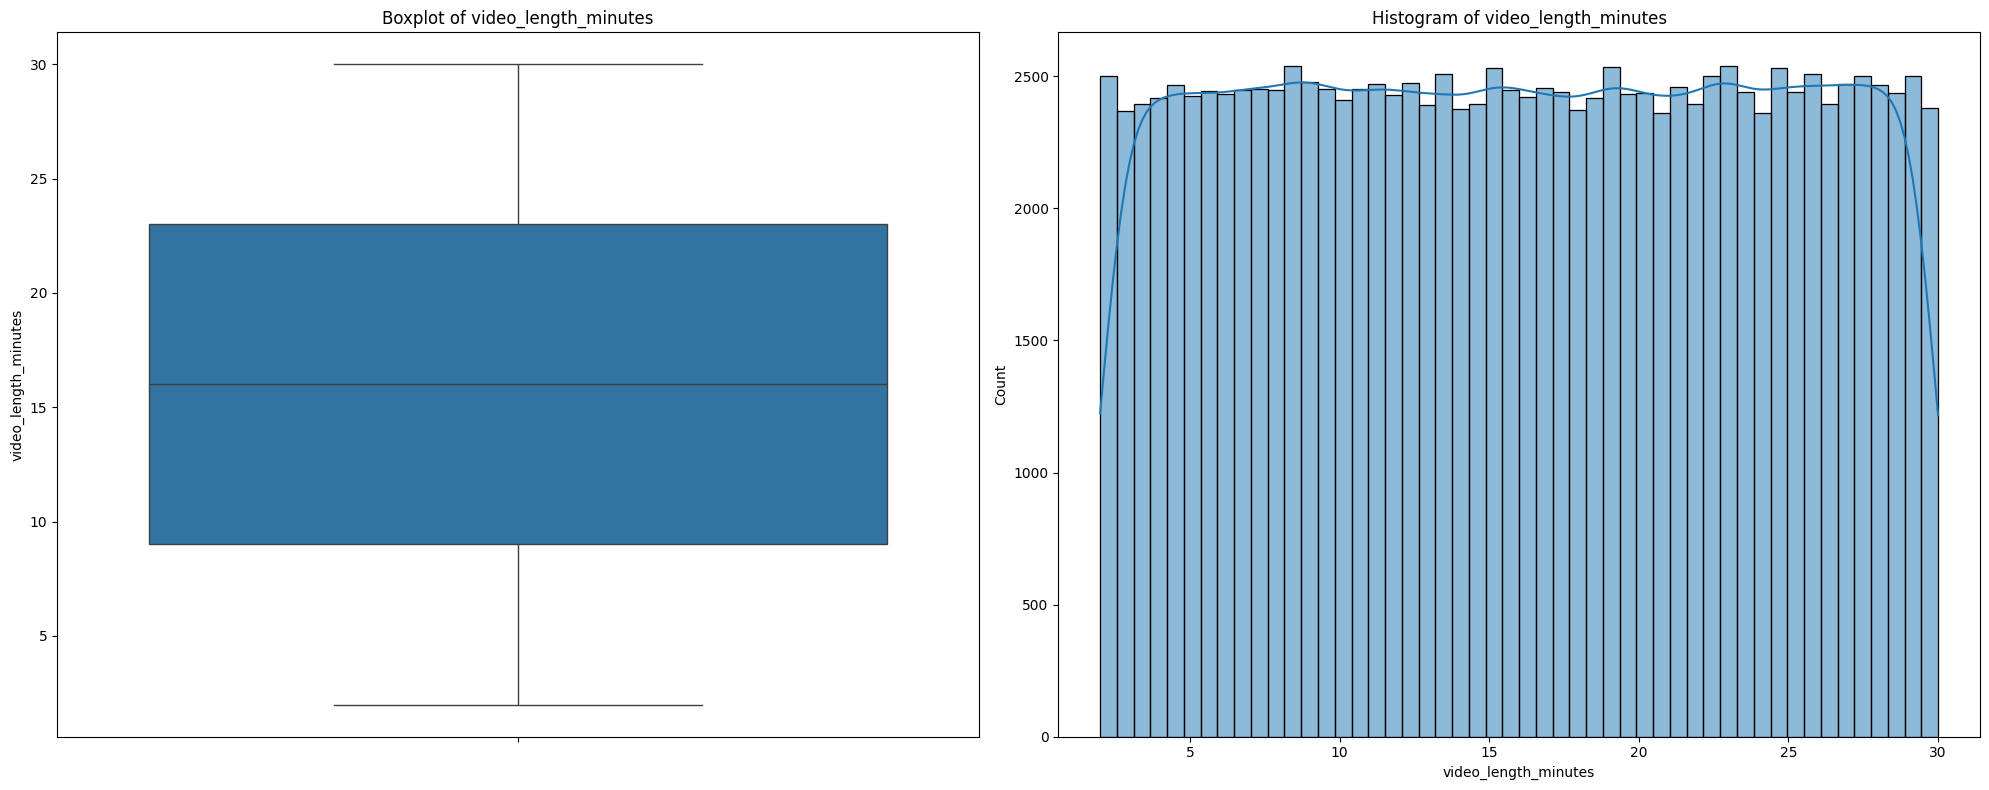

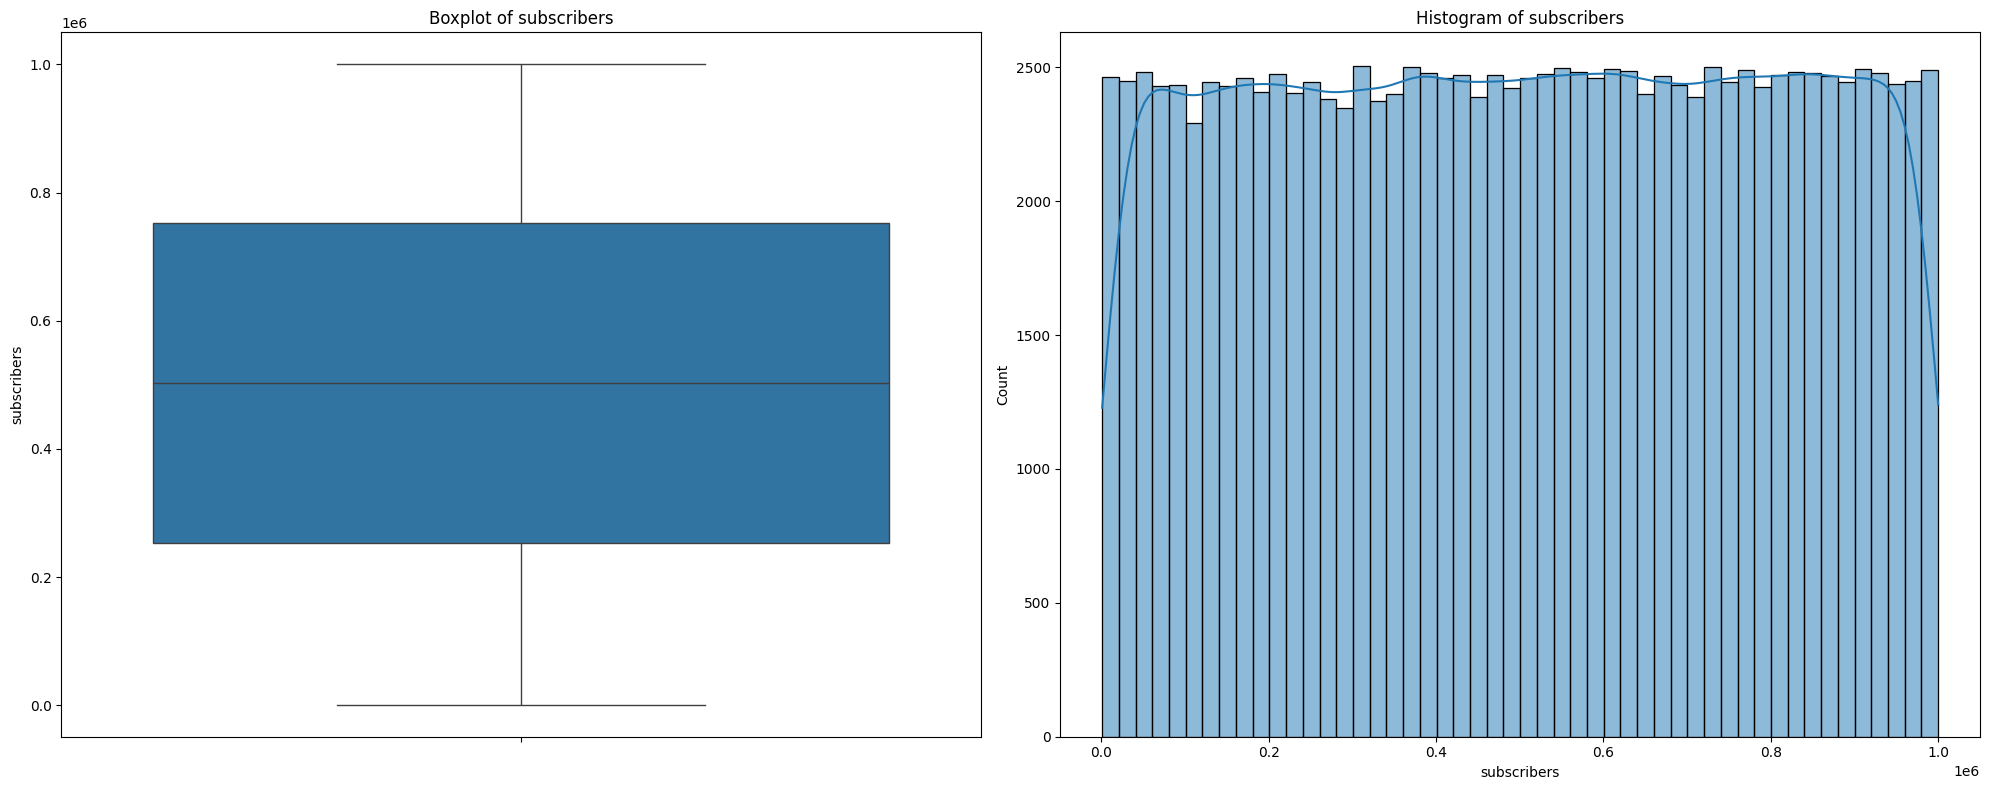

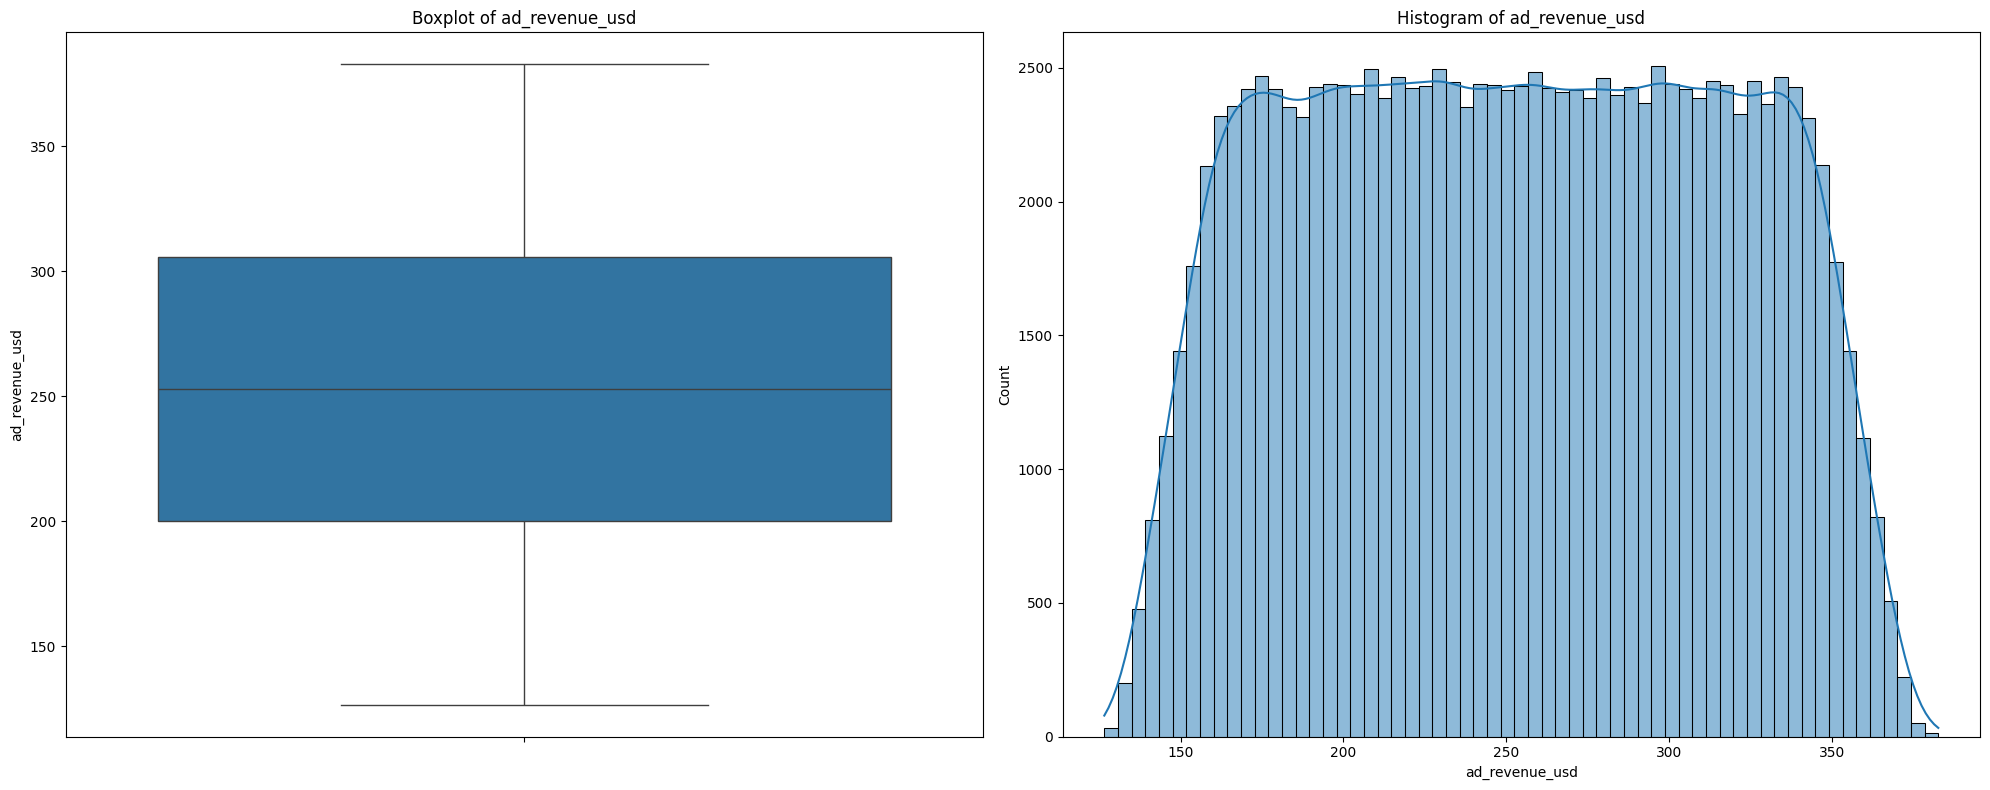

In [29]:
ploting = ['watch_time_minutes','video_length_minutes','subscribers',
           'ad_revenue_usd']
for col in ploting: 
    plt.figure(figsize=(20,8))
    # Boxplot
    plt.subplot(1,2,1)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')
    # Histogram (numeric) or Countplot (categorical)
    plt.subplot(1,2,2)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.show()


In [30]:
df['watch_time_minutes'].isnull().sum()

np.int64(0)

In [31]:
df['video_length_minutes'].isnull().sum()

np.int64(0)

In [32]:
df['subscribers'].isnull().sum()

np.int64(0)

In [33]:
df['category'].isnull().sum()

np.int64(0)

In [34]:
df['device'].isnull().sum()

np.int64(0)

In [35]:
df['country'].isnull().sum()

np.int64(0)

In [36]:
df['ad_revenue_usd'].isnull().sum()

np.int64(0)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   video_id              122400 non-null  object        
 1   date                  122400 non-null  datetime64[ns]
 2   views                 122400 non-null  int64         
 3   likes                 122400 non-null  int64         
 4   comments              122400 non-null  float64       
 5   watch_time_minutes    122400 non-null  float64       
 6   video_length_minutes  122400 non-null  float64       
 7   subscribers           122400 non-null  int64         
 8   category              122400 non-null  object        
 9   device                122400 non-null  object        
 10  country               122400 non-null  object        
 11  ad_revenue_usd        122400 non-null  float64       
 12  likes_clean           122400 non-null  object        
dtyp

In [38]:
df['subscribers']=df['subscribers'].astype(int)

In [39]:
df['comments']=df['comments'].astype(int)

In [40]:
df['likes']=df['likes'].astype(int)

In [41]:
df['views']=df['views'].astype(int)

In [42]:
df.drop(columns='likes_clean', inplace=True)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   video_id              122400 non-null  object        
 1   date                  122400 non-null  datetime64[ns]
 2   views                 122400 non-null  int64         
 3   likes                 122400 non-null  int64         
 4   comments              122400 non-null  int64         
 5   watch_time_minutes    122400 non-null  float64       
 6   video_length_minutes  122400 non-null  float64       
 7   subscribers           122400 non-null  int64         
 8   category              122400 non-null  object        
 9   device                122400 non-null  object        
 10  country               122400 non-null  object        
 11  ad_revenue_usd        122400 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memo

In [44]:
df = df.drop_duplicates()

In [45]:
#Future Engineering
# converting "date" which consists of Dtype "datetime64" for the StandardScaler for  Numerical columns 
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day
df['hour']=df['date'].dt.hour
df['minute']=df['date'].dt.minute

In [46]:
#Future Engineering

df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']

In [47]:
df['avg_watch_time_per_view'] = df['watch_time_minutes'] / df['views']


In [48]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,year,month,day,hour,minute,engagement_rate,avg_watch_time_per_view
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,2024,9,24,10,50,0.155093,2.666789
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,2024,9,22,10,50,0.098632,1.518393
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008,2024,11,21,10,50,0.214519,5.678187
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,2025,1,28,10,50,0.142814,3.122834
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,2025,4,28,10,50,0.236121,1.584151


In [49]:
df2=df.copy()


In [50]:
#separating the numirical columns
num_cols = df2.select_dtypes(include='number').columns


In [51]:
#StandardScaler for Numerical  cloumns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2[num_cols] = scaler.fit_transform(df2[num_cols])

In [52]:
# One‑Hot Encoding for categorical columns
cat_cols = ['category', 'device', 'country'] 
# One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder
df2= pd.get_dummies(df2, columns=cat_cols, drop_first=True, dtype=int)
df2.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,year,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,vid_3092,2024-09-24 10:50:40.993199,-0.638847,0.238712,0.359351,-0.867324,-1.627204,-0.950903,-0.799516,-0.877982,...,0,0,0,1,0,0,0,1,0,0
1,vid_3459,2024-09-22 10:50:40.993199,0.171818,-0.898679,0.563871,-1.754151,0.954887,0.810515,-1.805067,-0.877982,...,0,0,0,0,1,1,0,0,0,0
2,vid_4784,2024-11-21 10:50:40.993199,0.972474,1.727731,-0.686846,1.555338,1.259475,-0.907735,1.733913,-0.877982,...,0,0,0,1,0,1,0,0,0,0
3,vid_4078,2025-01-28 10:50:40.993199,0.341957,0.179780,-0.254208,-0.487269,-0.525371,-0.235154,-0.453129,1.138976,...,0,0,1,0,0,0,0,0,1,0
4,vid_3522,2025-04-28 10:50:40.993199,-1.109233,1.490038,1.594335,-1.718330,-1.160443,-1.596116,-1.407450,1.138976,...,0,0,1,0,0,1,0,0,0,0


In [53]:
#Pearson correlation
# Example: select only numeric columns of interest
selected_cols = ['views', 'likes', 'comments', 'watch_time_minutes',                 
                 'video_length_minutes','subscribers','ad_revenue_usd',
                 'year','month','day'                                  
                 ]

# Compute Pearson correlation matrix
corr_matrix = df2[selected_cols].corr(method='pearson')

print(corr_matrix)


                         views     likes  comments  watch_time_minutes  \
views                 1.000000  0.015913  0.018143            0.026735   
likes                 0.015913  1.000000 -0.001681            0.003022   
comments              0.018143 -0.001681  1.000000           -0.000306   
watch_time_minutes    0.026735  0.003022 -0.000306            1.000000   
video_length_minutes  0.001171  0.001548 -0.002237           -0.001049   
subscribers           0.000750  0.003349 -0.001769            0.004335   
ad_revenue_usd        0.037942  0.142151  0.033483            0.958739   
year                 -0.007280 -0.005181 -0.004958            0.001803   
month                 0.004141  0.005625  0.004461           -0.000264   
day                   0.003629  0.002866  0.001711           -0.002552   

                      video_length_minutes  subscribers  ad_revenue_usd  \
views                             0.001171     0.000750        0.037942   
likes                             0

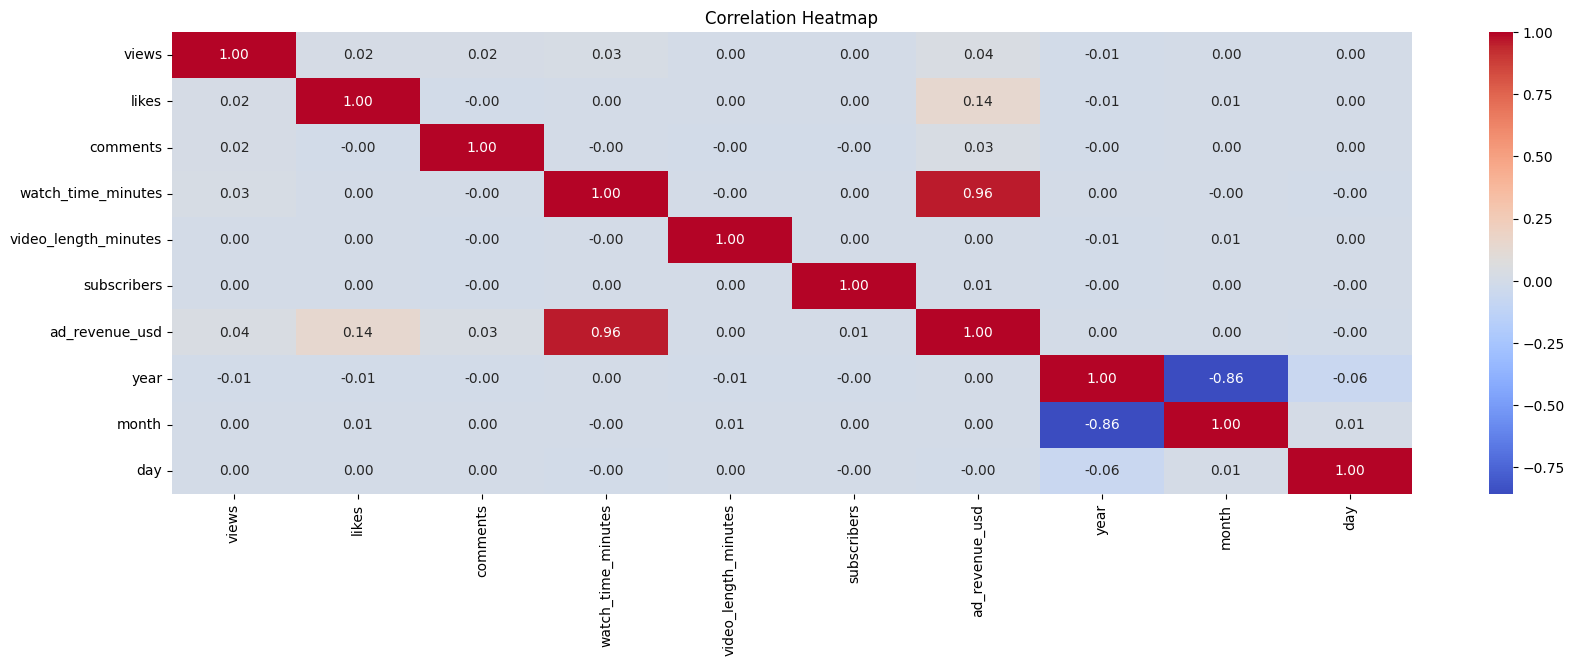

In [54]:
# Plot heatmap
plt.figure(figsize=(20,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [55]:
df_1=df2.copy()

In [56]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 29 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   video_id                 120000 non-null  object        
 1   date                     120000 non-null  datetime64[ns]
 2   views                    120000 non-null  float64       
 3   likes                    120000 non-null  float64       
 4   comments                 120000 non-null  float64       
 5   watch_time_minutes       120000 non-null  float64       
 6   video_length_minutes     120000 non-null  float64       
 7   subscribers              120000 non-null  float64       
 8   ad_revenue_usd           120000 non-null  float64       
 9   year                     120000 non-null  float64       
 10  month                    120000 non-null  float64       
 11  day                      120000 non-null  float64       
 12  hour                 

In [57]:
# Features
from sklearn.model_selection import train_test_split

X = df_1.drop(columns=['video_id','date','day','hour','minute','ad_revenue_usd'])
y = df_1['ad_revenue_usd']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
#KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
knn = KNeighborsRegressor(n_neighbors=5)
#fit the model
knn.fit(X_train, y_train)
#Making predictions
y_pred = knn.predict(X_test)
#evalution 
knn_mae = mean_absolute_error(y_test, y_pred)
knn_mse = mean_squared_error(y_test, y_pred)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, y_pred)
print('KNeighborsRegressor')
print("Mean Absolute Error (MAE):", knn_mae)
print("Mean Squared Error (MSE):", knn_mse)
print("Root Mean Squared Error (RMSE):", knn_rmse)
print("R² Score:", knn_r2)


KNeighborsRegressor
Mean Absolute Error (MAE): 0.20155486298989017
Mean Squared Error (MSE): 0.10082060815509415
Root Mean Squared Error (RMSE): 0.3175226104627734
R² Score: 0.8990002899377807


In [59]:
#KNeighborsRegressor Train Vs Test Score

Knn_train_score = knn.score(X_train, y_train)
Knn_test_score = knn.score(X_test, y_test)
print("print('KNeighborsRegressor")
print("KNN_train_score:", Knn_train_score)
print("KNN_test_score:", Knn_train_score)

print('KNeighborsRegressor
KNN_train_score: 0.9306425672114996
KNN_test_score: 0.9306425672114996


In [78]:
#DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
dt_squared_error = DecisionTreeRegressor(criterion='squared_error', max_depth=3, random_state=42)
#fit the model
dt_squared_error.fit(X_train, y_train)
##Making predictions
y_pred_squared_error= dt_squared_error.predict(X_test)
#evalution 
dt_mae = mean_absolute_error(y_test, y_pred)
dt_mse = mean_squared_error(y_test, y_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred)
print('DecisionTreeRegressor')
print("Mean Absolute Error (MAE):", dt_mae)
print("Mean Squared Error (MSE):", dt_mse)
print("Root Mean Squared Error (RMSE):", dt_rmse)
print("R² Score:", dt_r2)



DecisionTreeRegressor
Mean Absolute Error (MAE): 0.20155486298989017
Mean Squared Error (MSE): 0.10082060815509415
Root Mean Squared Error (RMSE): 0.3175226104627734
R² Score: 0.8990002899377807


In [61]:
#DecisionTreeRegressor Train Vs Test Score
dt_train_score = dt_squared_error.score(X_train, y_train)
dt_test_score = dt_squared_error.score(X_test, y_test)
print("DecisionTreeRegressor")
print("DT_train_score:", dt_train_score)
print("DT_test_score:", dt_test_score)

DecisionTreeRegressor
DT_train_score: 0.9045539421256248
DT_test_score: 0.9047260524295796


In [79]:
#RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=50,oob_score=True,random_state=42,n_jobs=1)
#fit the model
rf.fit(X_train,y_train)
##Making predictions
y_pred = rf.predict(X_test)
#evalution 
rf_mae = mean_absolute_error(y_test, y_pred)
rf_mse = mean_squared_error(y_test, y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred)
print('RandomForestRegressor')
print("Mean Absolute Error (MAE):", rf_mae)
print("Mean Squared Error (MSE):", rf_mse)
print("Root Mean Squared Error (RMSE):", rf_rmse)
print("R² Score:", rf_r2)



RandomForestRegressor
Mean Absolute Error (MAE): 0.08770068112890002
Mean Squared Error (MSE): 0.06296050580721509
Root Mean Squared Error (RMSE): 0.25091932131108413
R² Score: 0.9369276485406908


In [63]:
#RandomForestRegressor Train Vs Test Score

rf_train_score = rf.score(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)
print("RandomForestRegressor")
print("RF_train_score:", rf_train_score)
print("RF_test_score:", rf_test_score)

RandomForestRegressor
RF_train_score: 0.990487780415542
RF_test_score: 0.9369276485406908


In [80]:
#GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
gb = GradientBoostingRegressor(n_estimators=50,random_state=42) 
# Fit the model
gb.fit(X_train, y_train)
# Predict
y_pred = gb.predict(X_test)
#evalution 
gb_mae = mean_absolute_error(y_test, y_pred)
gb_mse = mean_squared_error(y_test, y_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred)
print('GradientBoostingRegressor')
print("Mean Absolute Error (MAE):", gb_mae)
print("Mean Squared Error (MSE):", gb_mse)
print("Root Mean Squared Error (RMSE):", gb_rmse)
print("R² Score:", gb_r2)


GradientBoostingRegressor
Mean Absolute Error (MAE): 0.07984835108174679
Mean Squared Error (MSE): 0.05929997419311103
Root Mean Squared Error (RMSE): 0.24351586024961708
R² Score: 0.9405946828748752


In [84]:
#GradientBoostingRegressor Train Vs Test Score

gb_train_score = gb.score(X_train, y_train)
gb_test_score = gb.score(X_test, y_test)
print("GradientBoostingRegressor")
print("GB_train_score:", gb_train_score)
print("GB_test_score:", gb_test_score)

GradientBoostingRegressor
GB_train_score: 0.9398993965735527
GB_test_score: 0.9405946828748752


In [81]:
#ExtraTreesRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = ExtraTreesRegressor(n_estimators=50,  max_depth=10, random_state=42,n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

et_mae = mean_absolute_error(y_test, y_pred)
et_mse = mean_squared_error(y_test, y_pred)
et_rmse = np.sqrt(et_mse)
et_r2 = r2_score(y_test, y_pred)

print("ExtraTreesRegressor")
print("Mean Absolute Error (MAE):", et_mae)
print("Mean Squared Error (MSE):", et_mse)
print("Root Mean Squared Error (RMSE):", et_rmse)
print("R² Score:", et_r2)





ExtraTreesRegressor
Mean Absolute Error (MAE): 0.07646408412061827
Mean Squared Error (MSE): 0.05912800040486426
Root Mean Squared Error (RMSE): 0.24316249794091246
R² Score: 0.9407669621644874


In [85]:
#ExtraTreesRegressor Train Vs Test Score
et_train_score = model.score(X_train, y_train)
et_test_score = model.score(X_test, y_test)
print("ExtraTreesRegressor")
print("ETR_train_score:", et_train_score)
print("ETR_test_score:", et_test_score)

ExtraTreesRegressor
ETR_train_score: 0.9438551629201086
ETR_test_score: 0.9407669621644874


In [82]:
# Framing the result into a DataFrame 'Regression_Results'
Regression_Results=pd.DataFrame([
   
     ['KNN Regression',knn_r2,knn_mae,knn_mse,knn_rmse,],
      ['Decision Tree',dt_r2,dt_mae,dt_mse,dt_rmse,],
       ['Random Forest',rf_r2,rf_mae,rf_mse,rf_rmse,],
       ['Gradient Boosting',gb_r2,gb_mae,gb_mse,gb_rmse,],
       ['ExtraTreesRegressor',et_r2,et_mae,et_mse,et_rmse,],
       ],columns=["Model", "R² Score", "MAE", "MSE", "RMSE"])   




In [83]:
Regression_Results

,Model,R² Score,MAE,MSE,RMSE
0,KNN Regression,0.899000,0.201555,0.100821,0.317523
1,Decision Tree,0.899000,0.201555,0.100821,0.317523
2,Random Forest,0.936928,0.087701,0.062961,0.250919
3,Gradient Boosting,0.940595,0.079848,0.059300,0.243516
4,ExtraTreesRegressor,0.940767,0.076464,0.059128,0.243162


In [86]:
# Framing the result into a DataFrame 'Train_Vs_Test'

Train_Vs_Test = pd.DataFrame([
    ['KNN Regression', Knn_train_score, Knn_test_score],
    ['Decision Tree', dt_train_score, dt_test_score],
    ['Random Forest', rf_train_score, rf_test_score],
    ['Gradient Boosting', gb_train_score, gb_test_score],
    ['ExtraTreesRegressor', et_train_score, et_test_score],
], columns=["Model", "Training_Score", "Test_Score"])


In [87]:
Train_Vs_Test

,Model,Training_Score,Test_Score
0,KNN Regression,0.930643,0.899000
1,Decision Tree,0.904554,0.904726
2,Random Forest,0.990488,0.936928
3,Gradient Boosting,0.939899,0.940595
4,ExtraTreesRegressor,0.943855,0.940767


In [72]:
# load your cleansed DataFrame into SQL before applying StandardScaler and One‑Hot Encoding

from sqlalchemy import create_engine

# Replace with your actual credentials
user = "root"
password = "root"
host = "localhost"
port = "3306"
database = "content_monetization_modeler"

# Create SQLAlchemy engine
engine = create_engine(f"mysql+pymysql://root:root@{host}:3306/content_monetization_modeler")
# Write the cleaned DataFrame to the SQL table
df.to_sql(name='content_monetization_modeler', con=engine, if_exists='replace', index=False)
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,year,month,day,hour,minute,engagement_rate,avg_watch_time_per_view
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,2024,9,24,10,50,0.155093,2.666789
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,2024,9,22,10,50,0.098632,1.518393
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008,2024,11,21,10,50,0.214519,5.678187
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,2025,1,28,10,50,0.142814,3.122834
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,2025,4,28,10,50,0.236121,1.584151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673,147,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,2024,12,14,10,50,0.184715,4.270345
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709,63,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,2024,7,13,10,50,0.174961,5.683620
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700,297,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,2024,6,10,10,50,0.097107,2.683327
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616,106,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,2024,12,22,10,50,0.168164,5.563221


In [73]:
# load your cleansed DataFrame into SQL Regression_Results for Streamlit application view
from sqlalchemy import create_engine

# Replace with your actual credentials
user = "root"
password = "root"
host = "localhost"
port = "3306"
database = "content_monetization_modeler"

# Create SQLAlchemy engine
engine = create_engine(f"mysql+pymysql://root:root@{host}:3306/content_monetization_modeler")
# Write the cleaned DataFrame to the SQL table
Regression_Results.to_sql(name='regression_results', con=engine, if_exists='replace', index=False)
Regression_Results

,Model,R² Score,MAE,MSE,RMSE
0,KNN Regression,0.940767,0.076464,0.059128,0.243162
1,Decision Tree,0.940767,0.076464,0.059128,0.243162
2,Random Forest,0.940767,0.076464,0.059128,0.243162
3,Gradient Boosting,0.940767,0.076464,0.059128,0.243162
4,ExtraTreesRegressor,0.940767,0.076464,0.059128,0.243162


In [74]:
## load your cleansed DataFrame into SQL Train_Vs_Test for Streamlit application view

from sqlalchemy import create_engine

# Replace with your actual credentials
user = "root"
password = "root"
host = "localhost"
port = "3306"
database = "content_monetization_modeler"

# Create SQLAlchemy engine
engine = create_engine(f"mysql+pymysql://root:root@{host}:3306/content_monetization_modeler")
# Write the cleaned DataFrame to the SQL table
Train_Vs_Test.to_sql(name='train_vs_test', con=engine, if_exists='replace', index=False)
Train_Vs_Test

,Model,Training_Score,Test_Score
0,KNN Regression,0.930643,0.899000
1,Decision Tree,0.904554,0.904726
2,Random Forest,0.990488,0.936928
3,Gradient Boosting,0.939899,0.940595
4,ExtraTreesRegressor,0.943855,0.940767


In [75]:
## load your cleansed DataFrame into SQL Train_Vs_Test for Streamlit application view

from sqlalchemy import create_engine

# Replace with your actual credentials
user = "root"
password = "root"
host = "localhost"
port = "3306"
database = "content_monetization_modeler"

# Create SQLAlchemy engine
engine = create_engine(f"mysql+pymysql://root:root@{host}:3306/content_monetization_modeler")
# Write the cleaned DataFrame to the SQL table
Train_Vs_Test.to_sql(name='train_vs_test', con=engine, if_exists='replace', index=False)
Train_Vs_Test

,Model,Training_Score,Test_Score
0,KNN Regression,0.930643,0.899000
1,Decision Tree,0.904554,0.904726
2,Random Forest,0.990488,0.936928
3,Gradient Boosting,0.939899,0.940595
4,ExtraTreesRegressor,0.943855,0.940767


In [76]:
import joblib
import os
#save the model
save_folder = r"D:\DS_Content_Monetization_Modeler\ML_Trained_Models"

joblib.dump(model, os.path.join(save_folder, "ExtraTreesRegressor.pkl"))
joblib.dump(knn, os.path.join(save_folder, "KNeighborsRegressor_model.pkl"))
joblib.dump(dt_squared_error, os.path.join(save_folder, "DecisionTreeRegressor_model.pkl"))
joblib.dump(rf, os.path.join(save_folder, "RandomForestRegressor_model.pkl"))
joblib.dump(gb, os.path.join(save_folder, "GradientBoostingRegressor.pkl"))


['D:\\DS_Content_Monetization_Modeler\\ML_Trained_Models\\GradientBoostingRegressor.pkl']